## 1 Environment checks

In [18]:
!apt-get -y install cuda-nsight-systems-12-8 2>&1 | tail -3
!nsys --version

Reading state information...
cuda-nsight-systems-12-8 is already the newest version (12.8.2-1).
0 upgraded, 0 newly installed, 0 to remove and 100 not upgraded.
NVIDIA Nsight Systems version 2024.6.2.225-246235244400v0


In [19]:
!nvidia-smi
!nsys --version
!ncu --version
!python -c "import torch; print('torch', torch.__version__, 'cuda', torch.version.cuda, 'gpu', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE')"


Sat May  9 13:03:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2 Import repo and install dependencies


In [9]:
import os, sys, subprocess, pathlib
REPO = "/content/tph-yolov5"
if not pathlib.Path(REPO).exists():
    !git clone https://github.com/yeungsinchun/tph-yolov5 {REPO}
%cd {REPO}
!pip -q install -r requirements.txt
!pip -q install fvcore nvtx pandas matplotlib seaborn


/content/tph-yolov5


## 3 Test the inference to verify the output is correct


In [10]:
!cd /content/tph-yolov5
!python detect.py \
    --weights yolov5l-xs-1.pt \
    --source VisDrone/sample_val \
    --img 1536 --device 0 \
    --conf-thres 0.25 --iou-thres 0.45 \
    --name smoke --exist-ok
!ls runs/detect/smoke


detect: weights=['yolov5l-xs-1.pt'], source=VisDrone/sample_val, imgsz=[1536, 1536], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=smoke, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
YOLOv5 🚀 d08c705 torch 2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model Summary: 570 layers, 60425780 parameters, 0 gradients, 145.7 GFLOPs
image 1/2 /content/tph-yolov5/VisDrone/sample_val/0000001_02999_d_0000005.jpg: 864x1536 6 pedestrians, 17 peoples, 1 bicycle, 14 cars, 3 vans, 2 trucks, 61 motors, Done. (0.190s)
image 2/2 /content/tph-yolov5/VisDrone/sample_val/0000162_00801_d_0000001.jpg: 864x1536 3 pedestrians, 4 peoples, 8 cars, 3 vans, 6 trucks, 2 tricycles, 3 motors, Done. (0.178s)
Speed: 1.2ms pre-process, 183.6ms inference, 32.0ms NMS per 

## 4 Pytorch profiler


In [11]:
!python profiling/profile_inference.py \
    --weights yolov5l-xs-1.pt \
    --source VisDrone/sample_val \
    --img 1536 --device 0 \
    --iters 30 --warmup 5 \
    --torch-profiler \
    --out profiling/runs/baseline_fp32


YOLOv5 🚀 d08c705 torch 2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

[profile] device=cuda:0 half=False
Fusing layers... 
Model Summary: 570 layers, 60425780 parameters, 0 gradients, 145.7 GFLOPs
[profile] cached 2 images at 1536px
/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
[W509 12:57:19.795255439 CPUAllocator.cpp:245] Memory block of unknown size was allocated before the profiling started, profiler results will not include the deallocation event
[profile] torch trace -> profiling/runs/baseline_fp32/torch_trace.json
{
  "weights": "yolov5l-xs-1.pt",
  "imgsz": 1536,
  "half": false,
  "device": "cuda:0",
  "iters": 30,
  "stages": {
    "preprocess": {
      "mean_ms": 1.3727351332818216,
      "median_ms": 1.2812914999358327,
      "p95_ms": 1.4514526499397107,
      "std_ms"

            mean_ms  median_ms  p95_ms  std_ms
preprocess     1.37       1.28    1.45    0.37
inference    185.57     185.84  187.70    2.00
nms            4.30       2.48    3.75    9.31
d2h            0.11       0.11    0.17    0.03
total        191.36     189.64  192.50   10.47

Device: Tesla T4  Peak GPU memory: 1046.4 MB


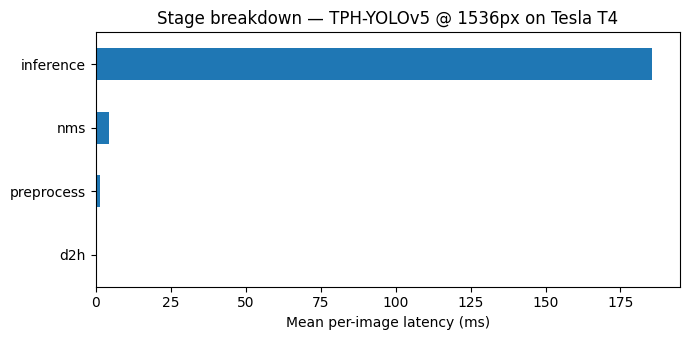

In [12]:
import json, pandas as pd, matplotlib.pyplot as plt
s = json.load(open('profiling/runs/baseline_fp32/summary.json'))
df = pd.DataFrame(s['stages']).T[['mean_ms', 'median_ms', 'p95_ms', 'std_ms']]
print(df.round(2))
print(f"\nDevice: {s['device_name']}  Peak GPU memory: {s['peak_memory_MB']:.1f} MB")

fig, ax = plt.subplots(figsize=(7, 3.5))
df_plot = df.drop('total').sort_values('mean_ms')
df_plot['mean_ms'].plot.barh(ax=ax)
ax.set_xlabel('Mean per-image latency (ms)')
ax.set_title(f'Stage breakdown — TPH-YOLOv5 @ 1536px on {s["device_name"]}')
plt.tight_layout(); plt.savefig('profiling/runs/baseline_fp32/stage_breakdown.png', dpi=160)
plt.show()


In [20]:
print(open('profiling/runs/baseline_fp32/torch_key_averages.txt').read())


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us        5.110s       101.80%        5.110s     189.246ms           0 B           0 B           0 B           0 

In [14]:
!nsys profile --stats=true -t cuda,nvtx,osrt,cudnn,cublas \
    -o profiling/runs/baseline_fp32/nsys_report \
    --force-overwrite true \
    python profiling/profile_inference.py \
        --weights yolov5l-xs-1.pt \
        --source VisDrone/sample_val \
        --img 1536 --device 0 \
        --iters 20 --warmup 5 \
        --out profiling/runs/baseline_fp32_nsys 2>&1 | tail -120


      0.9       47,406,150      1,711      27,706.7      6,324.0        304    4,008,892     211,545.0  cudaMemsetAsync                  
      0.3       15,673,825         87     180,158.9    167,109.0      6,734      478,669      70,397.6  cudaMalloc                       
      0.2        8,317,815          7   1,188,259.3    652,911.0    139,920    5,206,877   1,790,424.0  cuLibraryUnload                  
      0.1        6,259,333          3   2,086,444.3  2,332,219.0  1,446,796    2,480,318     558,879.1  cudaGetDeviceProperties_v2_v12000
      0.1        4,453,401          2   2,226,700.5  2,226,700.5     16,186    4,437,215   3,126,139.6  cudaFree                         
      0.0        1,644,662          2     822,331.0    822,331.0     17,058    1,627,604   1,138,828.0  cudaHostAlloc                    
      0.0          522,297      1,676         311.6        272.5        127        7,742         251.1  cuGetProcAddress_v2              
      0.0          228,517        

In [22]:
REP = 'profiling/runs/baseline_fp32/nsys_report.nsys-rep'
OUT = 'profiling/runs/baseline_fp32'
!nsys stats --force-export=true --report cuda_gpu_kern_sum --format csv --output {OUT}/nsys_kernels {REP}
!nsys stats --force-export=true --report cuda_gpu_mem_time_sum --format csv --output {OUT}/nsys_memops {REP}
!ls {OUT}/nsys_*


Generating SQLite file profiling/runs/baseline_fp32/nsys_report.sqlite from profiling/runs/baseline_fp32/nsys_report.nsys-rep
Processing [profiling/runs/baseline_fp32/nsys_report.sqlite] with [/opt/nvidia/nsight-systems/2024.6.2/host-linux-x64/reports/cuda_gpu_kern_sum.py] to [profiling/runs/baseline_fp32/nsys_kernels_cuda_gpu_kern_sum.csv]... PROCESSED

Generating SQLite file profiling/runs/baseline_fp32/nsys_report.sqlite from profiling/runs/baseline_fp32/nsys_report.nsys-rep
Processing [profiling/runs/baseline_fp32/nsys_report.sqlite] with [/opt/nvidia/nsight-systems/2024.6.2/host-linux-x64/reports/cuda_gpu_mem_time_sum.py] to [profiling/runs/baseline_fp32/nsys_memops_cuda_gpu_mem_time_sum.csv]... PROCESSED

profiling/runs/baseline_fp32/nsys_kernels_cuda_gpu_kern_sum.csv
profiling/runs/baseline_fp32/nsys_memops_cuda_gpu_mem_time_sum.csv
profiling/runs/baseline_fp32/nsys_report.nsys-rep
profiling/runs/baseline_fp32/nsys_report.sqlite


In [25]:
import pandas as pd, glob
kfile = glob.glob('profiling/runs/baseline_fp32/nsys_kernels*.csv')[0]
k = pd.read_csv(kfile)
print('Top kernels by total GPU time')
print(k.head(10).to_string(index=False))
HOT = k.iloc[0]['Name']
print(HOT)


Top kernels by total GPU time
 Time (%)  Total Time (ns)  Instances  Avg (ns)  Med (ns)  Min (ns)  Max (ns)  StdDev (ns)                                                                                                                                                                                                                                                                                                                     Name
     16.4        911189305       1983  459500.4  295198.0     52064   3632266     489354.3                                                                                                                                                                                                                                                                                                    volta_sgemm_128x64_nn
     14.4        801521289        843  950796.3  843066.0     33856   3036077     357187.3                                                                        

## 5 Nsight Compute

In [27]:
HOT_REGEX = "volta_sgemm_128x64"
!ncu --launch-count 1 --launch-skip 10 \
     --kernel-name regex:"{HOT_REGEX}" \
     --set full \
     --target-processes all \
     -o profiling/runs/baseline_fp32/ncu_hotkernel \
     --force-overwrite \
     python profiling/profile_inference.py \
        --weights yolov5l-xs-1.pt \
        --source VisDrone/sample_val \
        --img 1536 --device 0 \
        --iters 12 --warmup 4 \
        --out profiling/runs/baseline_fp32_ncu 2>&1 | tail -40


  "stages": {
    "preprocess": {
      "mean_ms": 2.1509001667633734,
      "median_ms": 2.0367360000363988,
      "p95_ms": 2.8799634500728644,
      "std_ms": 0.4934400563136616
    },
    "inference": {
      "mean_ms": 190.59490974984783,
      "median_ms": 183.74566649981716,
      "p95_ms": 223.18484184986568,
      "std_ms": 23.576378780422935
    },
    "nms": {
      "mean_ms": 30.068923750074344,
      "median_ms": 10.041670499958855,
      "p95_ms": 121.55002575004784,
      "std_ms": 68.15176059211339
    },
    "d2h": {
      "mean_ms": 0.16938700002810947,
      "median_ms": 0.14775149998058623,
      "p95_ms": 0.29760925031041535,
      "std_ms": 0.07882698369284631
    },
    "total": {
      "mean_ms": 222.98412066671366,
      "median_ms": 196.0567030000675,
      "p95_ms": 347.30470274998856,
      "std_ms": 91.7961093135116
    }
  },
  "mean_detections_per_image": 66.5,
  "peak_memory_MB": 1046.36865234375,
  "reserved_memory_MB": 2028.0,
  "device_name": "Tesla T

In [28]:
!ncu --import profiling/runs/baseline_fp32/ncu_hotkernel.ncu-rep \
     --csv --page details > profiling/runs/baseline_fp32/ncu_metrics.csv 2>/dev/null
!ncu --import profiling/runs/baseline_fp32/ncu_hotkernel.ncu-rep \
     --csv --page details \
     --metrics sm__throughput.avg.pct_of_peak_sustained_elapsed,gpu__compute_memory_throughput.avg.pct_of_peak_sustained_elapsed,l1tex__t_sector_hit_rate.pct,lts__t_sector_hit_rate.pct,smsp__average_warps_active.avg,smsp__warps_eligible.sum.per_cycle_active,launch__registers_per_thread,launch__shared_mem_per_block_static \
     > profiling/runs/baseline_fp32/ncu_key_metrics.csv 2>/dev/null
!head -20 profiling/runs/baseline_fp32/ncu_key_metrics.csv


"ID","Process ID","Process Name","Host Name","Kernel Name","Context","Stream","Block Size","Grid Size","Device","CC","Section Name","Metric Name","Metric Unit","Metric Value","Rule Name","Rule Type","Rule Description","Estimated Speedup Type","Estimated Speedup"
"0","17074","python3.12","127.0.0.1","volta_sgemm_128x64_nn","1","7","(128, 1, 1)","(8, 4, 1)","0","7.5","GPU Speed Of Light Throughput","Memory Throughput","%","29.86",
"0","17074","python3.12","127.0.0.1","volta_sgemm_128x64_nn","1","7","(128, 1, 1)","(8, 4, 1)","0","7.5","GPU Speed Of Light Throughput","Compute (SM) Throughput","%","61.58",
"0","17074","python3.12","127.0.0.1","volta_sgemm_128x64_nn","1","7","(128, 1, 1)","(8, 4, 1)","0","7.5","SpeedOfLight","","","","SOLBottleneck","OPT","Compute is more heavily utilized than Memory: Look at the Compute Workload Analysis section to see what the compute pipelines are spending their time doing. Also, consider whether any computation is redundant and could be reduced or moved 

In [29]:
import pandas as pd
m = pd.read_csv('profiling/runs/baseline_fp32/ncu_key_metrics.csv')
cols = ['Kernel Name','Metric Name','Metric Value']
cols = [c for c in cols if c in m.columns] or list(m.columns[:3])
pivot = m.pivot_table(index='Kernel Name', columns='Metric Name', values='Metric Value', aggfunc='first')
print(pivot.round(2).to_string())


Metric Name            Compute (SM) Throughput  L1/TEX Hit Rate  L2 Hit Rate  Memory Throughput  Registers Per Thread  Static Shared Memory Per Block
Kernel Name                                                                                                                                          
volta_sgemm_128x64_nn                    61.58              0.0        83.96              29.86                 122.0                           12.54


## 6 Roofline analysis

In [30]:
import torch, json
from fvcore.nn import FlopCountAnalysis, parameter_count_table
import sys; sys.path.insert(0, '/content/tph-yolov5')
from models.experimental import attempt_load
device = torch.device('cuda')
model = attempt_load('yolov5l-xs-1.pt', map_location=device).eval()
x = torch.zeros(1, 3, 1536, 1536, device=device)
flops = FlopCountAnalysis(model, x).total()  # MACs ≈ FLOPs/2 in fvcore
flops_total = flops * 2  # convert MACs → FLOPs (fvcore reports MACs)
params = sum(p.numel() for p in model.parameters())
print(f'Params: {params/1e6:.2f} M')
print(f'Total FLOPs (1×3×1536×1536, fp32): {flops_total/1e9:.2f} GFLOPs')


model.37.m.tr.0.ma.out_proj, model.37.m.tr.1.ma.out_proj, model.37.m.tr.2.ma.out_proj, model.9.m.tr.0.ma.out_proj, model.9.m.tr.1.ma.out_proj, model.9.m.tr.2.ma.out_proj


Params: 60.43 M
Total FLOPs (1×3×1536×1536, fp32): 931.98 GFLOPs


In [31]:
# Combine measured time with FLOPs to get achieved FLOP/s.
s = json.load(open('profiling/runs/baseline_fp32/summary.json'))
inf_ms = s['stages']['inference']['mean_ms']
achieved_flops = flops_total / (inf_ms / 1000.0)
print(f'Mean forward time: {inf_ms:.2f} ms')
print(f'Achieved throughput: {achieved_flops/1e12:.2f} TFLOP/s (fp32)')

# Hardware peaks — adjust to whatever GPU nvidia-smi showed you:
peaks = {
    'NVIDIA A100':  {'fp32': 19.5e12,  'fp16': 312e12,  'bw_GBs': 1555},
    'NVIDIA L4':    {'fp32': 30e12,    'fp16': 121e12,  'bw_GBs': 300},
    'Tesla T4':     {'fp32': 8.1e12,   'fp16': 65e12,   'bw_GBs': 320},
}
name = s['device_name']
peak = next((v for k,v in peaks.items() if k in name), peaks['NVIDIA L4'])
print(f'Using peak spec for {name}: {peak}')
print(f'Utilisation of fp32 peak: {achieved_flops/peak["fp32"]*100:.1f}%')


Mean forward time: 185.57 ms
Achieved throughput: 5.02 TFLOP/s (fp32)
Using peak spec for Tesla T4: {'fp32': 8100000000000.0, 'fp16': 65000000000000.0, 'bw_GBs': 320}
Utilisation of fp32 peak: 62.0%


In [32]:
# Quick model-level roofline plot. For a kernel-level one use ncu.
import numpy as np, matplotlib.pyplot as plt
pi  = peak['fp32']
beta= peak['bw_GBs']*1e9
AI  = np.logspace(-1, 3, 200)        # FLOPs/byte
roof = np.minimum(pi, beta*AI)
# crude bytes estimate: 4× params (weights read once) + 4× activation bytes.
activ_bytes_est = 4 * 1536*1536*3*16  # ~feature-map bytes (rough)
bytes_total = 4*params + activ_bytes_est
ai = flops_total/bytes_total
plt.figure(figsize=(6,4))
plt.loglog(AI, roof/1e12, 'k-', label=f'{name} fp32 roof')
plt.scatter([ai],[achieved_flops/1e12], c='red', s=80, zorder=5, label='TPH-YOLOv5 (measured)')
plt.xlabel('Arithmetic intensity (FLOPs/byte)'); plt.ylabel('TFLOP/s')
plt.title('Roofline — TPH-YOLOv5 fp32 inference @1536px'); plt.grid(True, which='both', ls=':')
plt.legend(); plt.tight_layout(); plt.savefig('profiling/runs/baseline_fp32/roofline.png', dpi=160)
plt.show()


## 7 Memory utilisation

In [33]:
import torch, sys, time
sys.path.insert(0, '/content/tph-yolov5')
from models.experimental import attempt_load
from utils.datasets import LoadImages
torch.cuda.empty_cache()
torch.cuda.memory._record_memory_history(max_entries=200_000)
model = attempt_load('yolov5l-xs-1.pt', map_location='cuda').eval()
ds = LoadImages('VisDrone/sample_val', img_size=1536, stride=64, auto=True)
with torch.no_grad():
    for i, (path, img, _, _, _) in enumerate(ds):
        x = torch.from_numpy(img).cuda().float()/255
        if x.ndim==3: x = x[None]
        _ = model(x)
        if i >= 5: break
torch.cuda.memory._dump_snapshot('profiling/runs/baseline_fp32/memory_snapshot.pickle')
torch.cuda.memory._record_memory_history(enabled=None)
print('peak allocated MB :', torch.cuda.max_memory_allocated()/1e6)
print('peak reserved  MB :', torch.cuda.max_memory_reserved()/1e6)


peak allocated MB : 1505.665536
peak reserved  MB : 1786.773504


## 8 Cache hit-rate

In [34]:
!ncu --launch-count 3 --launch-skip 10 \
     --kernel-name regex:"{HOT_REGEX}" \
     --metrics l1tex__t_sector_hit_rate.pct,lts__t_sector_hit_rate.pct,dram__bytes.sum.per_second,sm__throughput.avg.pct_of_peak_sustained_elapsed \
     --csv \
     --target-processes all \
     python profiling/profile_inference.py \
        --weights yolov5l-xs-1.pt --source VisDrone/sample_val \
        --img 1536 --device 0 --iters 8 --warmup 4 \
        --out profiling/runs/baseline_fp32 --no-summary --quiet \
     > profiling/runs/baseline_fp32/cache_metrics_raw.csv 2> profiling/runs/baseline_fp32/cache_metrics_stderr.log
import pandas as pd
from pathlib import Path
raw = Path('profiling/runs/baseline_fp32/cache_metrics_raw.csv')
clean = Path('profiling/runs/baseline_fp32/cache_metrics.csv')
lines = raw.read_text().splitlines()
start = next(i for i, line in enumerate(lines) if line.startswith('ID,') or line.startswith('\"ID\"'))
clean.write_text('\n'.join(lines[start:]) + '\n')
c = pd.read_csv(clean)
print(c.head(40).to_string())


    ID  Process ID Process Name  Host Name            Kernel Name  Context  Stream   Block Size  Grid Size  Device   CC                   Section Name                                       Metric Name Metric Unit       Metric Value
0    0       17607   python3.12  127.0.0.1  volta_sgemm_128x64_nn        1       7  (128, 1, 1)  (8, 4, 1)       0  7.5  Command line profiler metrics                        dram__bytes.sum.per_second      byte/s  29,275,545,851.53
1    0       17607   python3.12  127.0.0.1  volta_sgemm_128x64_nn        1       7  (128, 1, 1)  (8, 4, 1)       0  7.5  Command line profiler metrics                      l1tex__t_sector_hit_rate.pct           %                  0
2    0       17607   python3.12  127.0.0.1  volta_sgemm_128x64_nn        1       7  (128, 1, 1)  (8, 4, 1)       0  7.5  Command line profiler metrics                        lts__t_sector_hit_rate.pct           %              84.04
3    0       17607   python3.12  127.0.0.1  volta_sgemm_128x64_nn       

In [35]:
import time, json, os, csv
import torch
from models.experimental import attempt_load

device = torch.device('cuda:0')
model = attempt_load('yolov5l-xs-1.pt', map_location=device)
model.eval()

IMG = 1536
BATCH_SIZES = [1, 2, 4, 8]      # add 16 if memory allows
WARMUP, ITERS = 5, 20
results = []

with torch.inference_mode():
    for bs in BATCH_SIZES:
        try:
            x = torch.randn(bs, 3, IMG, IMG, device=device)
            for _ in range(WARMUP):
                model(x)
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            for _ in range(ITERS):
                model(x)
            torch.cuda.synchronize()
            dt = (time.perf_counter() - t0) / ITERS
            peak_mb = torch.cuda.max_memory_allocated() / 1e6
            torch.cuda.reset_peak_memory_stats()
            results.append({
                'batch': bs,
                'latency_ms_per_iter': dt * 1000,
                'latency_ms_per_img':  dt * 1000 / bs,
                'throughput_imgs_s':   bs / dt,
                'peak_mem_MB':         peak_mb,
            })
            print(f"bs={bs:>3}  iter={dt*1000:7.2f} ms  per-img={dt*1000/bs:6.2f} ms  thr={bs/dt:6.1f} img/s  peak={peak_mb:.0f} MB")
            del x
            torch.cuda.empty_cache()
        except RuntimeError as e:
            print(f"bs={bs}: OOM or error -> {e}"); torch.cuda.empty_cache(); break

os.makedirs('profiling/runs/batch_sweep', exist_ok=True)
with open('profiling/runs/batch_sweep/sweep.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=results[0].keys()); w.writeheader(); w.writerows(results)
print('wrote profiling/runs/batch_sweep/sweep.csv')

bs=  1  iter= 359.87 ms  per-img=359.87 ms  thr=   2.8 img/s  peak=1730 MB
bs=  2  iter= 739.44 ms  per-img=369.72 ms  thr=   2.7 img/s  peak=2796 MB
bs=  4  iter=1548.40 ms  per-img=387.10 ms  thr=   2.6 img/s  peak=4928 MB
bs=  8  iter=3272.19 ms  per-img=409.02 ms  thr=   2.4 img/s  peak=9194 MB
wrote profiling/runs/batch_sweep/sweep.csv


In [36]:
import pandas as pd, matplotlib.pyplot as plt, os
os.makedirs('report/figures', exist_ok=True)
df = pd.read_csv('profiling/runs/batch_sweep/sweep.csv')
fig, ax1 = plt.subplots(figsize=(6, 3.6))
ax2 = ax1.twinx()
ax1.plot(df['batch'], df['latency_ms_per_img'], 'o-', color='tab:red',  label='Latency per image (ms)')
ax2.plot(df['batch'], df['throughput_imgs_s'],  's--', color='tab:blue', label='Throughput (img/s)')
ax1.set_xlabel('Batch size'); ax1.set_xscale('log', base=2); ax1.set_xticks(df['batch']); ax1.set_xticklabels(df['batch'])
ax1.set_ylabel('Latency per image (ms)', color='tab:red')
ax2.set_ylabel('Throughput (img/s)',      color='tab:blue')
ax1.set_title('TPH-YOLOv5 batch-size sensitivity (T4, FP32, 1536px)')
ax1.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('report/figures/batch_sweep.png', dpi=180)
plt.show()
print(df.to_string(index=False))

 batch  latency_ms_per_iter  latency_ms_per_img  throughput_imgs_s  peak_mem_MB
     1           359.871636          359.871636           2.778769  1730.481664
     2           739.442569          369.721285           2.704740  2796.081664
     4          1548.402981          387.100745           2.583307  4928.098816
     8          3272.190018          409.023752           2.444846  9193.705984


## 9 Optimisation experiment

In [37]:
!python profiling/profile_inference.py \
    --weights yolov5l-xs-1.pt --source VisDrone/sample_val \
    --img 1536 --device 0 --iters 30 --warmup 5 \
    --half \
    --out profiling/runs/opt_fp16
!nsys profile --stats=true -t cuda,nvtx,cudnn,cublas \
     -o profiling/runs/opt_fp16/nsys_report --force-overwrite true \
     python profiling/profile_inference.py \
        --weights yolov5l-xs-1.pt --source VisDrone/sample_val \
        --img 1536 --device 0 --iters 20 --warmup 5 --half \
        --out profiling/runs/opt_fp16_nsys 2>&1 | tail -30


YOLOv5 🚀 d08c705 torch 2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

[profile] device=cuda:0 half=True
Fusing layers... 
Model Summary: 570 layers, 60425780 parameters, 0 gradients, 145.7 GFLOPs
[profile] cached 2 images at 1536px
{
  "weights": "yolov5l-xs-1.pt",
  "imgsz": 1536,
  "half": true,
  "device": "cuda:0",
  "iters": 30,
  "stages": {
    "preprocess": {
      "mean_ms": 1.1671685666139335,
      "median_ms": 1.1499225001898594,
      "p95_ms": 1.288511149914484,
      "std_ms": 0.05431429058537788
    },
    "inference": {
      "mean_ms": 102.71522153340509,
      "median_ms": 101.29594750060278,
      "p95_ms": 103.42449815025248,
      "std_ms": 7.546934295184347
    },
    "nms": {
      "mean_ms": 3.3522050666154732,
      "median_ms": 1.5571819994875113,
      "p95_ms": 2.313360300377098,
      "std_ms": 9.522457179968425
    },
    "d2h": {
      "mean_ms": 0.08027126659726491,
      "median_ms": 0.07114950039976975,
      "p95_ms": 0.11621949979598863,
      "std_ms": 

In [38]:
import json, pandas as pd
a = json.load(open('profiling/runs/baseline_fp32/summary.json'))
b = json.load(open('profiling/runs/opt_fp16/summary.json'))
rows = []
for k in ['preprocess','inference','nms','d2h','total']:
    rows.append({'stage': k,
                 'fp32_ms': a['stages'][k]['mean_ms'],
                 'fp16_ms': b['stages'][k]['mean_ms'],
                 'speedup': a['stages'][k]['mean_ms']/b['stages'][k]['mean_ms']})
cmp = pd.DataFrame(rows).round(2)
print(cmp.to_string(index=False))
print(f"Peak mem: fp32={a['peak_memory_MB']:.0f}MB  fp16={b['peak_memory_MB']:.0f}MB")


     stage  fp32_ms  fp16_ms  speedup
preprocess     1.37     1.17     1.18
 inference   185.57   102.72     1.81
       nms     4.30     3.35     1.28
       d2h     0.11     0.08     1.41
     total   191.36   107.31     1.78
Peak mem: fp32=1046MB  fp16=656MB


In [41]:
!nsys stats --force-export=true --report cuda_gpu_kern_sum --format csv \
     --output profiling/runs/opt_fp16/nsys_kernels \
     profiling/runs/opt_fp16/nsys_report.nsys-rep

Generating SQLite file profiling/runs/opt_fp16/nsys_report.sqlite from profiling/runs/opt_fp16/nsys_report.nsys-rep
Processing [profiling/runs/opt_fp16/nsys_report.sqlite] with [/opt/nvidia/nsight-systems/2024.6.2/host-linux-x64/reports/cuda_gpu_kern_sum.py] to [profiling/runs/opt_fp16/nsys_kernels_cuda_gpu_kern_sum.csv]... SKIPPED: output file profiling/runs/opt_fp16/nsys_kernels_cuda_gpu_kern_sum.csv exists.

